# Step 4 — Data Visualization

**Goal:** To make insightful charts to support the analysis done in step 3, saved to
`reports/figures/` for the final report.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("..")
from src.analysis import add_financial_metrics
from src import viz

movies = pd.read_csv("../data/processed/movies_clean.csv", parse_dates=["release_date"])
movies = add_financial_metrics(movies)
movies["franchise"] = np.where(movies["belongs_to_collection"].notna(), "Franchise", "Standalone")
len(movies)

18

## 4.1 Revenue vs. Budget
A **scatter plot** to observed these two numeric variables on all the 18 movies. Every movie here is far above the break-even diagonal (revenue = budget).

saved -> reports/figures/01_revenue_vs_budget.png


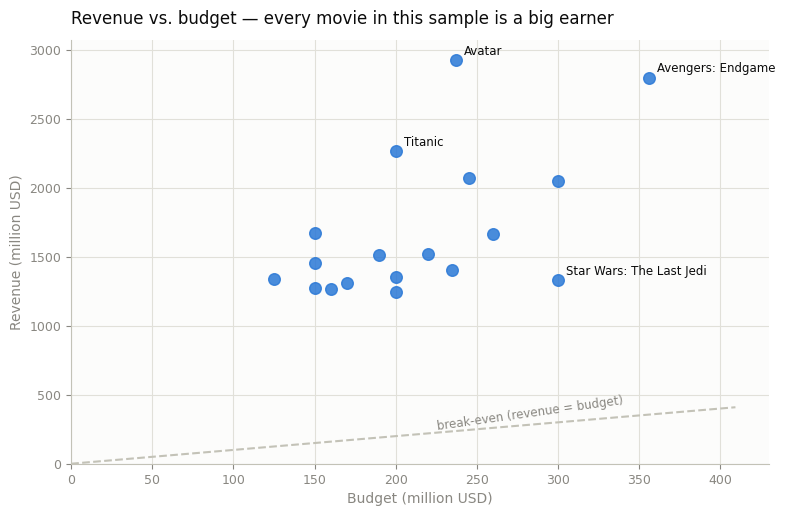

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(movies["budget_musd"], movies["revenue_musd"], s=70, color=viz.BLUE, alpha=0.85, zorder=3)

# break-even reference: above the line = profitable
lims = [0, movies["budget_musd"].max() * 1.15]
ax.plot(lims, lims, color=viz.BASELINE, linewidth=1.5, linestyle="--", zorder=2)
ax.annotate("break-even (revenue = budget)", (lims[1] * 0.55, lims[1] * 0.55),
            fontsize=8.5, color=viz.MUTED, rotation=8, va="bottom")

viz.label_points(ax, movies, ["Avatar", "Avengers: Endgame", "Titanic", "Star Wars: The Last Jedi"],
                 x="budget_musd", y="revenue_musd")

ax.set_xlim(0, None); ax.set_ylim(0, None)
viz.apply_style(ax, title="Revenue vs. budget — every movie in this sample is a big earner",
                xlabel="Budget (million USD)", ylabel="Revenue (million USD)")
viz.save_fig(fig, "01_revenue_vs_budget.png")
plt.show()

 All dots
sit far above the break-even line only because this sample contains no flops. 

The most expensive
   movie (Endgame, 356 M$) was out-earned by Avatar which had a comparably smaller 
   budget,
   and The Last Jedi spent 300 M$ to earn less than half of what Titanic made on 200 M$.


## 4.2 ROI distribution by genre

One movie carries several genres (`'Action|Adventure|...'`), so we reuse the
**`.explode()`**  to unravel them and visualise.


saved -> reports/figures/02_roi_by_genre.png


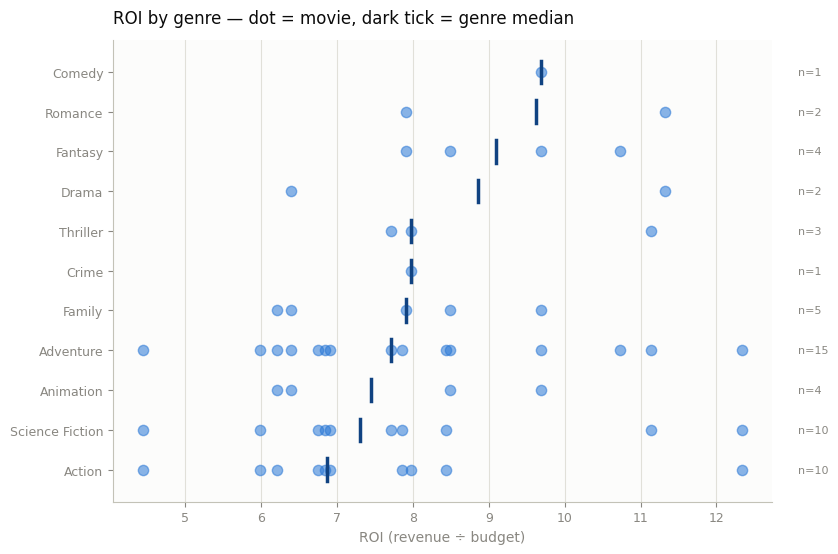

In [3]:
by_genre = (
    movies.assign(genre=movies["genres"].str.split("|"))
    .explode("genre")
    .dropna(subset=["roi"])
)
order = by_genre.groupby("genre")["roi"].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8.5, 6))
for i, genre in enumerate(order):
    rois = by_genre.loc[by_genre["genre"] == genre, "roi"]
    ax.scatter(rois, [i] * len(rois), s=55, color=viz.BLUE, alpha=0.55, zorder=3)
    ax.plot([rois.median()] * 2, [i - 0.28, i + 0.28], color=viz.BLUE_DARK, linewidth=2.5, zorder=4)
    ax.text(by_genre["roi"].max() * 1.06, i, f"n={len(rois)}", fontsize=8, color=viz.MUTED, va="center")

ax.set_yticks(range(len(order)), order)
viz.apply_style(ax, title="ROI by genre — dot = movie, dark tick = genre median",
                xlabel="ROI (revenue \u00f7 budget)")
ax.grid(axis="y", visible=False)
viz.save_fig(fig, "02_roi_by_genre.png")
plt.show()

Across this sample, genres with lots of movies doesn't necessarily move with ROI. Genres with
enough movies (Adventure n=15, Action n=10, Science Fiction n=10) all
center on a median return of roughly 7–8× budget. The genres that appear to
outperform (Comedy 9.7×, Romance 9.6×) are represented by only one and two films
respectively.

## 4.3 Popularity vs. rating

Finding a relationship between popularity and rating

saved -> reports/figures/03_popularity_vs_rating.png


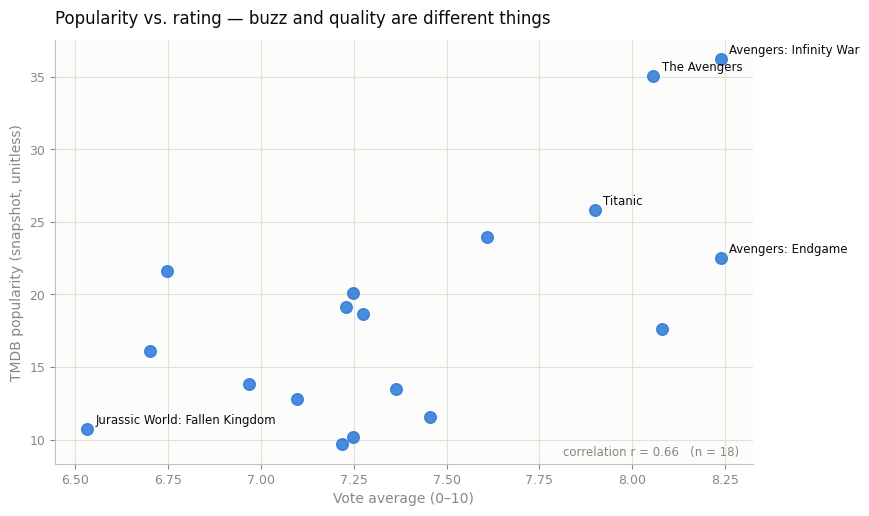

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(movies["vote_average"], movies["popularity"], s=70, color=viz.BLUE, alpha=0.85, zorder=3)

viz.label_points(ax, movies,
                 ["Avengers: Infinity War", "The Avengers", "Avengers: Endgame",
                  "Jurassic World: Fallen Kingdom", "Titanic"],
                 x="vote_average", y="popularity")

corr = movies["vote_average"].corr(movies["popularity"])
ax.text(0.98, 0.02, f"correlation r = {corr:.2f}   (n = {len(movies)})",
        transform=ax.transAxes, ha="right", fontsize=8.5, color=viz.MUTED)

viz.apply_style(ax, title="Popularity vs. rating — buzz and quality are different things",
                xlabel="Vote average (0\u201310)", ylabel="TMDB popularity (snapshot, unitless)")
viz.save_fig(fig, "03_popularity_vs_rating.png")
plt.show()

Given the scatter plot, we have a correlation `r = 0.66,` which is not far from mid. The anomaly proves the point because
Endgame is tied for the best rating in the sample (8.24) yet has barely half the
buzz of the identically-rated Infinity War  and The Avengers.

## 4.4 Yearly box-office trends

Total revenue per time bucket → **bars**. 

saved -> reports/figures/04_yearly_revenue.png


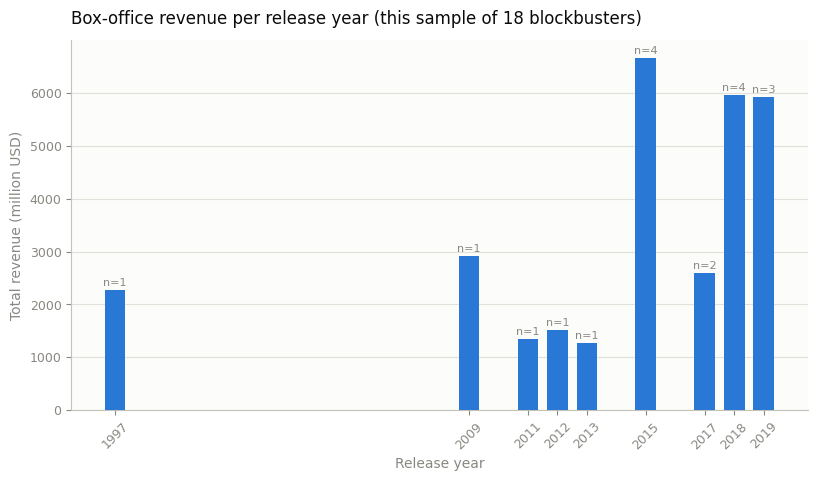

In [5]:
yearly = (
    movies.assign(year=movies["release_date"].dt.year)
    .groupby("year")
    .agg(total_revenue=("revenue_musd", "sum"), n_movies=("id", "count"))
)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar(yearly.index, yearly["total_revenue"], color=viz.BLUE, width=0.7, zorder=3)
for year, row in yearly.iterrows():
    ax.text(year, row["total_revenue"] + 80, f"n={int(row['n_movies'])}",
            ha="center", fontsize=8, color=viz.MUTED)

ax.set_xticks(yearly.index, yearly.index, rotation=45)
viz.apply_style(ax, title="Box-office revenue per release year (this sample of 18 blockbusters)",
                xlabel="Release year", ylabel="Total revenue (million USD)")
ax.grid(axis="x", visible=False)
viz.save_fig(fig, "04_yearly_revenue.png")
plt.show()

2015 peaks at 6.7 B\$ (4 movies), with
2018–2019 close behind. The empty
1998–2008 stretch means our id list contains no movies from those years, not that
the box office was quiet. 

## 4.5 Franchise vs. standalone

saved -> reports/figures/05_franchise_vs_standalone.png


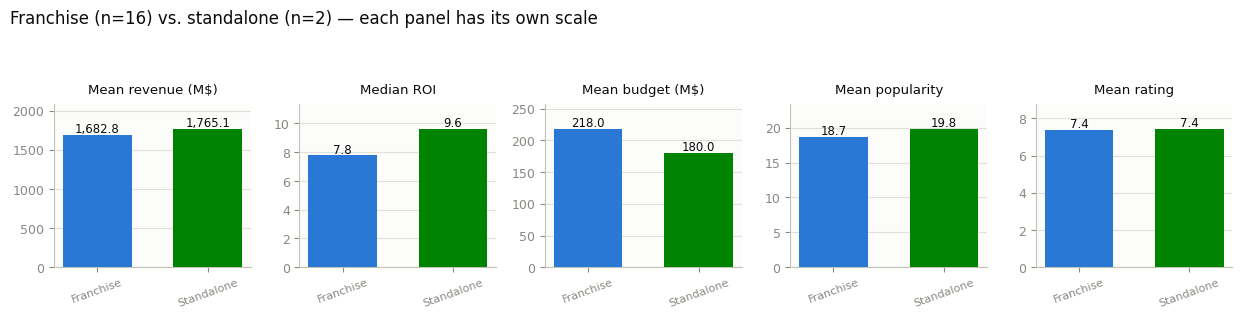

In [6]:
summary = movies.groupby("franchise").agg(
    **{
        "Mean revenue (M$)": ("revenue_musd", "mean"),
        "Median ROI": ("roi", "median"),
        "Mean budget (M$)": ("budget_musd", "mean"),
        "Mean popularity": ("popularity", "mean"),
        "Mean rating": ("vote_average", "mean"),
    }
)
colors = {"Franchise": viz.BLUE, "Standalone": viz.GREEN}

fig, axes = plt.subplots(1, 5, figsize=(12.5, 3.2))
for ax, metric in zip(axes, summary.columns):
    vals = summary[metric]
    ax.bar(vals.index, vals.values, color=[colors[g] for g in vals.index], width=0.62, zorder=3)
    for i, v in enumerate(vals.values):
        ax.text(i, v * 1.02, f"{v:,.1f}", ha="center", fontsize=8.5, color=viz.INK)
    ax.set_ylim(0, vals.max() * 1.18)
    viz.apply_style(ax, title=None)
    ax.set_title(metric, color=viz.INK, fontsize=9.5, pad=8)
    ax.tick_params(axis="x", labelsize=8, rotation=20)
    ax.grid(axis="x", visible=False)

fig.suptitle("Franchise (n=16) vs. standalone (n=2) — each panel has its own scale",
             x=0.01, ha="left", fontsize=12, color=viz.INK)
fig.tight_layout(rect=[0, 0, 1, 0.90])
viz.save_fig(fig, "05_franchise_vs_standalone.png")
plt.show()

For this sample, two standalone films  beat the
16 franchise films on every efficiency metric. Higher mean revenue ($1,765M vs
$1,683M), a clearly better median ROI (9.6× vs 7.8×), and a lower mean budget
($180M vs $218M) and popularity (19.8 vs 18.7).


---

All five figures are saved in `reports/figures/` and written up with these
insights in **`reports/final_report.md`**.